In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg') 


In [18]:
file_path = 'sales_data_sample.csv'
df_csv = pd.read_csv(file_path, encoding='ISO-8859-1')

print("=== Loaded CSV Data ===")
print(df_csv.columns)


=== Loaded CSV Data ===
Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')


In [19]:
conn = sqlite3.connect("sales_data.db")
df_csv.to_sql("sales", conn, if_exists="replace", index=False)

2823

In [20]:
query = """
SELECT PRODUCTLINE AS product,
       SUM(QUANTITYORDERED) AS total_qty,
       ROUND(SUM(SALES), 2) AS revenue
FROM sales
GROUP BY PRODUCTLINE
"""
df_summary = pd.read_sql_query(query, conn)
conn.close()

In [21]:
print("\n=== Sales Summary ===")
print(df_summary)


=== Sales Summary ===
            product  total_qty     revenue
0      Classic Cars      33992  3919615.66
1       Motorcycles      11663  1166388.34
2            Planes      10727   975003.57
3             Ships       8127   714437.13
4            Trains       2712   226243.47
5  Trucks and Buses      10777  1127789.84
6      Vintage Cars      21069  1903150.84


In [23]:
plt.figure(figsize=(10, 6))
plt.bar(df_summary['product'], df_summary['revenue'], color='orange')
plt.title("Revenue by Product")
plt.xlabel("Product Line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

# Save instead of show
plt.savefig("revenue_by_product.png")
print("Plot saved as 'revenue_by_product.png'")

Plot saved as 'revenue_by_product.png'


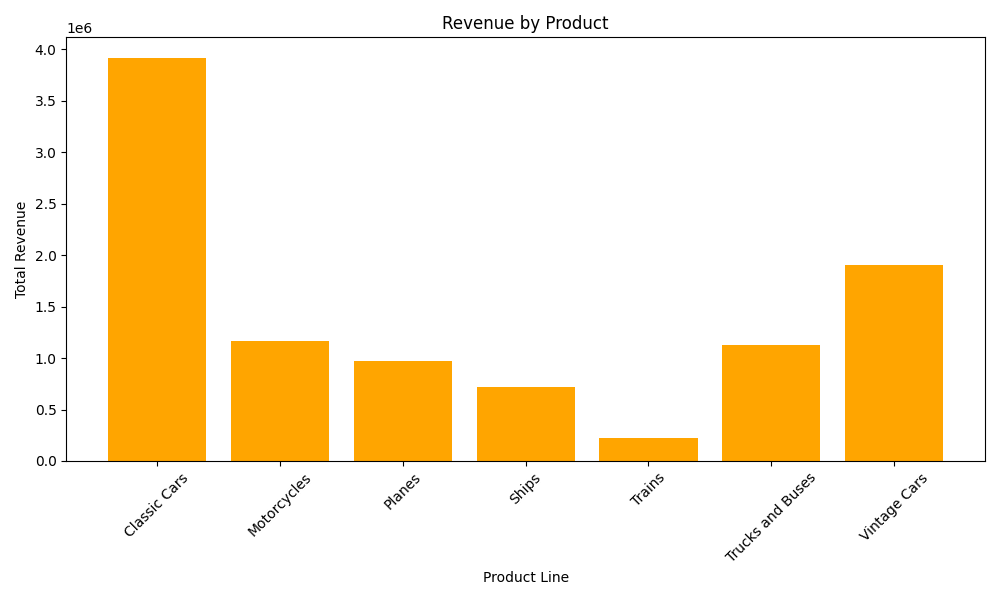

In [24]:
from IPython.display import Image
Image("revenue_by_product.png")
